# Notebook 1: Population, Sampling and Report Collection

## In this notebook, I will carry out the following activities

- Load and validate the FTSE 350 population dataset.
- Retain the variables required for the study.
- exclude companies with missing LSEG ESG scores or essential company information.
- Examine the eligible population by TRBC sector.
- Select a proportionate stratified candidate sample of 150 companies.
- Use a fixed random seed of 42 to make the sampling reproducible.
- use the official company websites recorded in the population dataset.
- Search for one eligible corporate report for each sampled company.
- Prioritise annual reports, followed by sustainability and ESG reports.
- Restrict eligible reports to the 2022–2025 reporting period.
- Prevent duplicate company and PDF downloads.
- Record the report URL, year, type, filename and collection status.
- Compare the sector allocation with the reports successfully collected.
- Export the report collection register for validation and text extraction in Notebook 2.

**Population source:** `Population Dataset.xlsx`  
**Candidate sample:** 150 companies  
**Minimum final analytical sample:** 100 companies  
**Eligible reporting period:** 2022–2025  
**Sampling method:** Proportionate stratified random sampling  
**Fixed random seed:** 42  
**Report rule:** One eligible report per company


## 1. Set Up the Project Folders and Core Libraries

I imported the core libraries and defined the folder structure for the analysis. I will save datasets in the data folder, figures in the output folder, corporate reports in the report folder and Jupyter notebooks in the notebook folder.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
PROJECT_COLOUR = "#1F4E78"

PROJECT_FOLDER = Path.home() / "Desktop" / "ESGProjectAnalysis"

DATA_FOLDER = PROJECT_FOLDER / "data"
OUTPUT_FOLDER = PROJECT_FOLDER / "output"
REPORT_FOLDER = PROJECT_FOLDER / "report"
NOTEBOOK_FOLDER = PROJECT_FOLDER / "notebook"

for folder in [DATA_FOLDER, OUTPUT_FOLDER, REPORT_FOLDER, NOTEBOOK_FOLDER]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Project folder: {PROJECT_FOLDER}")
print("Project subfolders are ready.")

Project folder: C:\Users\HP\Desktop\ESGProjectAnalysis
Project subfolders are ready.


## 2. Load and Display the Population Dataset

I loaded the FTSE 350 population dataset from the data folder and displayed the first five records to confirm that it was imported correctly.

In [2]:
population_file = DATA_FOLDER / "Population Dataset.xlsx"

population_df = pd.read_excel(
    population_file,
    sheet_name="Price Change Monitor"
)

print(f"Dataset shape: {population_df.shape}")
display(population_df.head())

Dataset shape: (350, 11)


,Identifier (RIC),Company Name,Company Website,Market Cap\n(Σ=Avg),1-day Price PCT Change\n(Σ=Avg),5-day Price PCT Change\n(Σ=Avg),TRBC Economic Sector Name,LSEG ESG Score\n(FY0)\n(Σ=None),Total Revenue per Share\n(FY0)\n(Σ=None),"Employees - Full-Time - Period End, 5 Yr CAGR\n(FY0)\n(Σ=None)",Country of Headquarters
0,SRP.L,Serco Group PLC,https://www.serco.com,2.372970e+09,0.008313,0.061242,Industrials,3.191950,4.713250,NaN,United Kingdom
1,KLR.L,Keller Group PLC,https://keller.com,2.243283e+09,-0.020619,-0.017640,Industrials,2.485106,42.998607,0.021296,United Kingdom
2,BP.L,BP PLC,https://www.bp.com,8.410285e+10,-0.025711,0.023759,Energy,3.996024,11.898134,0.080579,United Kingdom
3,PRN.L,Princes Group PLC,https://www.princesgroup.com,8.094665e+08,0.013825,0.018519,Consumer Non-Cyclicals,NaN,7.648175,NaN,United Kingdom
4,RCP.L,RIT Capital Partners PLC,https://www.ritcap.com,3.327437e+09,-0.027888,-0.059730,Financials,1.802013,3.700855,0.044849,United Kingdom


## 3. Check the Dataset Structure

I examined the number of rows and columns, column names, data types and non-missing observations to understand the structure of the population dataset.


In [3]:
print(f"Rows: {population_df.shape[0]}")
print(f"Columns: {population_df.shape[1]}\n")

population_df.info()

Rows: 350
Columns: 11

<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                                                        Non-Null Count  Dtype  
---  ------                                                        --------------  -----  
 0   Identifier (RIC)                                              350 non-null    str    
 1   Company Name                                                  350 non-null    str    
 2   Company Website                                               350 non-null    str    
 3   Market Cap
(Σ=Avg)                                            350 non-null    float64
 4   1-day Price PCT Change
(Σ=Avg)                                350 non-null    float64
 5   5-day Price PCT Change
(Σ=Avg)                                350 non-null    float64
 6   TRBC Economic Sector Name                                     350 non-null    str    
 7   LSEG ESG Score
(FY0)
(Σ=None)                              

## 4. Retain the Variables Required for the Study

I standardised the column headings and retained only the variables required for company identification, sampling, report collection, sector analysis and external validation.


In [4]:
# Standardise the original column headings
population_df.columns = (
    population_df.columns
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Retain and rename the required variables
population_df = population_df[
    [
        "Identifier (RIC)",
        "Company Name",
        "Company Website",
        "Market Cap (Σ=Avg)",
        "TRBC Economic Sector Name",
        "LSEG ESG Score (FY0) (Σ=None)"
    ]
].rename(columns={
    "Identifier (RIC)": "RIC",
    "Market Cap (Σ=Avg)": "Market Cap",
    "TRBC Economic Sector Name": "TRBC Sector",
    "LSEG ESG Score (FY0) (Σ=None)": "LSEG ESG Score"
})

print(f"Variables retained: {population_df.shape[1]}")
display(population_df.head())

Variables retained: 6


,RIC,Company Name,Company Website,Market Cap,TRBC Sector,LSEG ESG Score
0,SRP.L,Serco Group PLC,https://www.serco.com,2.372970e+09,Industrials,3.191950
1,KLR.L,Keller Group PLC,https://keller.com,2.243283e+09,Industrials,2.485106
2,BP.L,BP PLC,https://www.bp.com,8.410285e+10,Energy,3.996024
3,PRN.L,Princes Group PLC,https://www.princesgroup.com,8.094665e+08,Consumer Non-Cyclicals,NaN
4,RCP.L,RIT Capital Partners PLC,https://www.ritcap.com,3.327437e+09,Financials,1.802013


## 5. Check Missing Values and Duplicate Companies

I assessed missing values and duplicate company records before defining the eligible population. Companies without an LSEG ESG Score or essential identification information will be excluded before sampling.

In [5]:
missing_summary = pd.DataFrame({
    "Missing Values": population_df.isna().sum(),
    "Missing Percentage": population_df.isna().mean().mul(100).round(2)
})

display(missing_summary)

print(f"Duplicate RICs: {population_df['RIC'].duplicated().sum()}")
print(f"Duplicate company names: {population_df['Company Name'].duplicated().sum()}")

,Missing Values,Missing Percentage
RIC,0,0.00
Company Name,0,0.00
Company Website,0,0.00
Market Cap,0,0.00
TRBC Sector,0,0.00
LSEG ESG Score,15,4.29


Duplicate RICs: 0
Duplicate company names: 0


## 6. Identify Companies with Missing LSEG ESG Scores

I identified companies without an LSEG ESG Score because the score is required for the external validation stage. These companies will be excluded before the stratified candidate sample is selected.

In [6]:
missing_lseg_df = population_df[
    population_df["LSEG ESG Score"].isna()
].copy()

print(f"Companies with missing LSEG ESG Scores: {len(missing_lseg_df)}")

display(
    missing_lseg_df[
        ["RIC", "Company Name", "TRBC Sector", "LSEG ESG Score"]
    ]
)

Companies with missing LSEG ESG Scores: 15


,RIC,Company Name,TRBC Sector,LSEG ESG Score
3,PRN.L,Princes Group PLC,Consumer Non-Cyclicals,NaN
98,CORD.L,Cordiant Digital Infrastructure Ltd,Financials,NaN
99,UEM.L,Utilico Emerging Markets Trust PLC,Financials,NaN
100,OCIO.L,Oakley Capital Investments Ltd,Financials,NaN
133,MTLN.L,Metlen Energy & Metals PLC,Utilities,NaN
184,ROSE.L,Rosebank Industries PLC,Financials,NaN
195,JCH.L,Jpmorgan Claverhouse Investment Trust PLC,Financials,NaN
208,HAN.L,Hansa Investment Company Ltd,Financials,NaN
219,SSIT.L,Seraphim Space Investment Trust PLC,Financials,NaN
239,ATRAS.L,Schroder Asian Total Return Investment Company...,Financials,NaN


## 7. Create the Eligible Population

I excluded companies without an LSEG ESG Score and created the eligible population for stratified sampling. I also removed any duplicate company records as a final precaution.


In [7]:
eligible_df = (
    population_df
    .dropna(subset=[
        "RIC",
        "Company Name",
        "Company Website",
        "TRBC Sector",
        "LSEG ESG Score"
    ])
    .drop_duplicates(subset="Company Name")
    .reset_index(drop=True)
)

print(f"Original population: {len(population_df)}")
print(f"Companies excluded: {len(population_df) - len(eligible_df)}")
print(f"Eligible population: {len(eligible_df)}")

Original population: 350
Companies excluded: 15
Eligible population: 335


## 8. Examine the Eligible Population by Sector

I calculated the number and percentage of eligible companies in each TRBC sector. This distribution will be used to allocate the 150 candidate companies proportionately across the sectors.


In [8]:
sector_summary = (
    eligible_df["TRBC Sector"]
    .value_counts()
    .rename_axis("TRBC Sector")
    .reset_index(name="Eligible Companies")
)

sector_summary["Population Percentage"] = (
    sector_summary["Eligible Companies"] / len(eligible_df) * 100
).round(2)

display(sector_summary)
print(f"Total eligible companies: {sector_summary['Eligible Companies'].sum()}")

,TRBC Sector,Eligible Companies,Population Percentage
0,Financials,130,38.81
1,Consumer Cyclicals,51,15.22
2,Industrials,46,13.73
3,Technology,24,7.16
4,Real Estate,21,6.27
5,Consumer Non-Cyclicals,20,5.97
6,Basic Materials,17,5.07
7,Healthcare,11,3.28
8,Energy,8,2.39
9,Utilities,7,2.09


Total eligible companies: 335


## 9. Visualise the Eligible Population by Sector

I created a vertical bar chart to show how the eligible population was distributed across the TRBC sectors. I used the selected project colour consistently and saved the figure in the output folder.

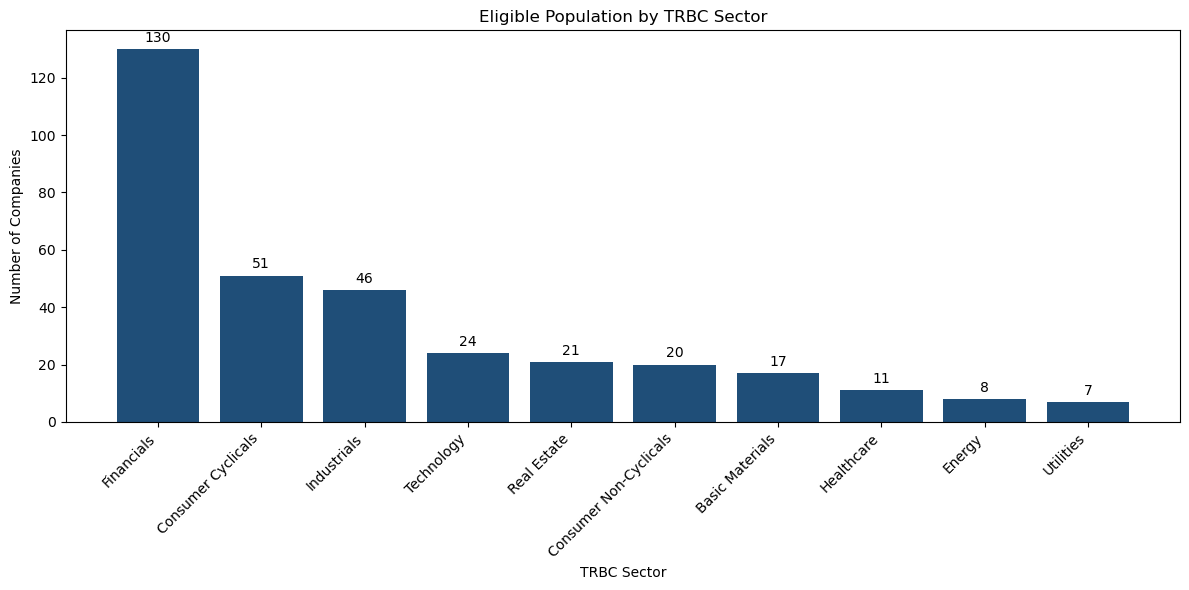

Chart saved as: Notebook01_Eligible_Population_by_Sector.png


In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    sector_summary["TRBC Sector"],
    sector_summary["Eligible Companies"],
    color=PROJECT_COLOUR
)

ax.bar_label(bars, padding=3)
ax.set_title("Eligible Population by TRBC Sector")
ax.set_xlabel("TRBC Sector")
ax.set_ylabel("Number of Companies")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

chart_file = OUTPUT_FOLDER / "Notebook01_Eligible_Population_by_Sector.png"
plt.savefig(chart_file, dpi=300, bbox_inches="tight")
plt.show()

print(f"Chart saved as: {chart_file.name}")

## 10. Calculate the Proportionate Sector Allocation

I allocated the 150 candidate companies proportionately across the TRBC sectors. I used the largest-remainder method to convert the proportional allocations into whole numbers while ensuring that the final allocation totalled exactly 150 companies.

In [10]:
TARGET_SAMPLE = 150

allocation_df = sector_summary.copy()

allocation_df["Exact Allocation"] = (
    allocation_df["Eligible Companies"]
    / allocation_df["Eligible Companies"].sum()
    * TARGET_SAMPLE
)

allocation_df["Candidate Sample"] = (
    np.floor(allocation_df["Exact Allocation"]).astype(int)
)

remaining_places = TARGET_SAMPLE - allocation_df["Candidate Sample"].sum()

largest_remainders = (
    allocation_df["Exact Allocation"]
    .sub(allocation_df["Candidate Sample"])
    .nlargest(remaining_places)
    .index
)

allocation_df.loc[largest_remainders, "Candidate Sample"] += 1
allocation_df["Exact Allocation"] = allocation_df["Exact Allocation"].round(2)

display(allocation_df)

print(f"Candidate sample allocation: {allocation_df['Candidate Sample'].sum()}")

,TRBC Sector,Eligible Companies,Population Percentage,Exact Allocation,Candidate Sample
0,Financials,130,38.81,58.21,58
1,Consumer Cyclicals,51,15.22,22.84,23
2,Industrials,46,13.73,20.60,21
3,Technology,24,7.16,10.75,11
4,Real Estate,21,6.27,9.40,9
5,Consumer Non-Cyclicals,20,5.97,8.96,9
6,Basic Materials,17,5.07,7.61,8
7,Healthcare,11,3.28,4.93,5
8,Energy,8,2.39,3.58,3
9,Utilities,7,2.09,3.13,3


Candidate sample allocation: 150


## 11. Select the Stratified Candidate Sample

I randomly selected the required number of companies from each TRBC sector using the proportional allocation. I used the fixed random seed of 42 to ensure that the same 150 companies can be reproduced whenever the notebook is rerun.

In [11]:
allocation_map = allocation_df.set_index(
    "TRBC Sector"
)["Candidate Sample"]

candidate_df = pd.concat(
    [
        sector_data.sample(
            n=int(allocation_map.loc[sector]),
            random_state=SEED
        )
        for sector, sector_data in eligible_df.groupby("TRBC Sector")
    ],
    ignore_index=True
)

candidate_df = (
    candidate_df
    .sort_values(["TRBC Sector", "Company Name"])
    .reset_index(drop=True)
)

candidate_df.insert(
    0,
    "Sample ID",
    [f"FTSE-{number:03d}" for number in range(1, len(candidate_df) + 1)]
)

print(f"Candidate companies selected: {len(candidate_df)}")
display(candidate_df.head(10))

Candidate companies selected: 150


,Sample ID,RIC,Company Name,Company Website,Market Cap,TRBC Sector,LSEG ESG Score
0,FTSE-001,ATYM.L,Atalaya Mining Copper SA,https://atalayamining.com,1.395645e+09,Basic Materials,3.033797
1,FTSE-002,BREE.L,Breedon Group PLC,https://www.breedongroup.com,1.115456e+09,Basic Materials,3.193617
2,FTSE-003,CRDA.L,Croda International PLC,https://www.croda.com,4.094183e+09,Basic Materials,3.686486
3,FTSE-004,GLEN.L,Glencore PLC,https://www.glencore.com,6.107874e+10,Basic Materials,3.812741
4,FTSE-005,HILS.L,Hill & Smith PLC,https://hsgroup.com,2.351415e+09,Basic Materials,2.492386
5,FTSE-006,MNDI.L,Mondi PLC,https://www.mondigroup.com,3.330964e+09,Basic Materials,3.625000
6,FTSE-007,PAFR.L,Pan African Resources PLC,https://www.panafricanresources.com,2.320077e+09,Basic Materials,2.757455
7,FTSE-008,RIO.L,Rio Tinto PLC,https://www.riotinto.com,1.171524e+11,Basic Materials,4.049702
8,FTSE-009,FOUR.L,4imprint Group PLC,https://4imprint.com,1.139784e+09,Consumer Cyclicals,3.747036
9,FTSE-010,AO.L,AO World plc,https://www.ao-world.com,5.454785e+08,Consumer Cyclicals,2.079897


## 12. Validate the Candidate Sample

I validated the candidate sample by confirming its total size, sector allocation, missing essential values and duplicate company records.

In [15]:
sample_validation = allocation_df[
    ["TRBC Sector", "Candidate Sample"]
].copy()

sample_validation["Selected Companies"] = (
    sample_validation["TRBC Sector"]
    .map(candidate_df["TRBC Sector"].value_counts())
)

sample_validation["Difference"] = (
    sample_validation["Selected Companies"]
    - sample_validation["Candidate Sample"]
)

# Add the total row
sample_validation.loc[len(sample_validation)] = [
    "Total",
    sample_validation["Candidate Sample"].sum(),
    sample_validation["Selected Companies"].sum(),
    sample_validation["Difference"].sum()
]

# Format and display the table
styled_validation = (
    sample_validation.style
    .hide(axis="index")
    .set_properties(
        subset=pd.IndexSlice[[sample_validation.index[-1]], :],
        **{
            "background-color": "#163A5C",
            "color": "white",
            "font-weight": "bold"
        }
    )
)

display(styled_validation)

print(f"Duplicate companies: {candidate_df['Company Name'].duplicated().sum()}")
print(f"Missing essential values: {candidate_df.isna().sum().sum()}")

TRBC Sector,Candidate Sample,Selected Companies,Difference
Financials,58,58,0
Consumer Cyclicals,23,23,0
Industrials,21,21,0
Technology,11,11,0
Real Estate,9,9,0
Consumer Non-Cyclicals,9,9,0
Basic Materials,8,8,0
Healthcare,5,5,0
Energy,3,3,0
Utilities,3,3,0


Duplicate companies: 0
Missing essential values: 0


## 13. Save the Validated Candidate Sample

I saved the frozen 150-company candidate sample, sector allocation and companies excluded because of missing LSEG ESG Scores in one Excel workbook. This creates a transparent sampling record for the report-collection stage.

In [16]:
sample_file = DATA_FOLDER / "Notebook01_150_Company_Candidate_Sample.xlsx"

with pd.ExcelWriter(sample_file) as writer:
    candidate_df.to_excel(
        writer,
        sheet_name="Candidate Sample",
        index=False
    )
    
    sample_validation.to_excel(
        writer,
        sheet_name="Sector Allocation",
        index=False
    )
    
    missing_lseg_df.to_excel(
        writer,
        sheet_name="Missing LSEG Scores",
        index=False
    )

print(f"Candidate sample saved as: {sample_file.name}")
print(f"Companies saved: {len(candidate_df)}")

Candidate sample saved as: Notebook01_150_Company_Candidate_Sample.xlsx
Companies saved: 150


## 14. Validate the Official Company Websites

I cleaned the official website addresses and checked that each address followed a valid HTTP or HTTPS format before beginning report discovery.

In [17]:
candidate_df["Company Website"] = (
    candidate_df["Company Website"]
    .astype(str)
    .str.strip()
    .str.rstrip("/")
)

invalid_websites = candidate_df[
    ~candidate_df["Company Website"].str.match(
        r"^https?://",
        case=False,
        na=False
    )
]

print(f"Valid website addresses: {len(candidate_df) - len(invalid_websites)}")
print(f"Invalid website addresses: {len(invalid_websites)}")

if not invalid_websites.empty:
    display(
        invalid_websites[
            ["Sample ID", "Company Name", "Company Website"]
        ]
    )

Valid website addresses: 150
Invalid website addresses: 0


## 15. Create the Report Collection Register

I created a report collection register for the 150 candidate companies. The register will track one eligible annual, sustainability or ESG report for each company during the 2022–2025 reporting period.

In [18]:
report_register = candidate_df.copy()

report_register["Report URL"] = ""
report_register["Report Year"] = pd.NA
report_register["Report Type"] = ""
report_register["Downloaded Filename"] = ""
report_register["File Path"] = ""
report_register["File Size Bytes"] = pd.NA
report_register["SHA256"] = ""
report_register["Download Status"] = "Not Started"

print(f"Companies in report register: {len(report_register)}")

display(
    report_register[
        [
            "Sample ID",
            "Company Name",
            "Company Website",
            "TRBC Sector",
            "Download Status"
        ]
    ].head()
)

Companies in report register: 150


,Sample ID,Company Name,Company Website,TRBC Sector,Download Status
0,FTSE-001,Atalaya Mining Copper SA,https://atalayamining.com,Basic Materials,Not Started
1,FTSE-002,Breedon Group PLC,https://www.breedongroup.com,Basic Materials,Not Started
2,FTSE-003,Croda International PLC,https://www.croda.com,Basic Materials,Not Started
3,FTSE-004,Glencore PLC,https://www.glencore.com,Basic Materials,Not Started
4,FTSE-005,Hill & Smith PLC,https://hsgroup.com,Basic Materials,Not Started


## 16. Save or Reload the Report Collection Register

I created a restart-safe report register. If a previous register exists, I reload it so that completed downloads are not repeated. Otherwise, I save the new register.

In [24]:
register_file = DATA_FOLDER / "Notebook01_Report_Collection_Register.xlsx"

if register_file.exists():
    saved_register = pd.read_excel(register_file)

    if set(saved_register["Sample ID"]) == set(report_register["Sample ID"]):
        report_register = saved_register
        print("Existing report register reloaded.")
    else:
        report_register.to_excel(register_file, index=False)
        print("A new report register was created.")
else:
    report_register.to_excel(register_file, index=False)
    print("A new report register was created.")

print(f"Companies in register: {len(report_register)}")
print(
    report_register["Download Status"]
    .fillna("Not Started")
    .value_counts()
)

Existing report register reloaded.
Companies in register: 150
Download Status
Not Started    150
Name: count, dtype: int64


## 17. Set Up the Report-Discovery Process

I defined the eligible reporting period, report priorities and web-request settings. I will search only the official company domains and retain one annual, sustainability or ESG report for each company.

In [25]:
import re
import time
import hashlib
import requests

from bs4 import BeautifulSoup
from urllib.parse import urljoin, urlparse

ELIGIBLE_YEARS = {"2022", "2023", "2024", "2025"}

REPORT_PRIORITY = {
    "Annual Report": 1,
    "Sustainability Report": 2,
    "ESG Report": 3
}

ORIGINAL_REPORT_FOLDER = REPORT_FOLDER / "original_reports"
ORIGINAL_REPORT_FOLDER.mkdir(exist_ok=True)

session = requests.Session()
session.headers.update({
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 Chrome/124.0 Safari/537.36"
    )
})

print(f"Eligible report years: {sorted(ELIGIBLE_YEARS)}")
print(f"Report folder: {ORIGINAL_REPORT_FOLDER}")

Eligible report years: ['2022', '2023', '2024', '2025']
Report folder: C:\Users\HP\Desktop\ESGProjectAnalysis\report\original_reports


## 18. Define the Report Identification Rules

I created simple functions to identify official company domains, classify eligible report types, extract eligible report years and generate safe PDF filenames.

In [26]:
def get_domain(url):
    domain = urlparse(url).netloc.lower().split(":")[0]
    return domain.removeprefix("www.")


def is_official_page(url, company_website):
    page_domain = get_domain(url)
    official_domain = get_domain(company_website)

    return (
        page_domain == official_domain
        or page_domain.endswith("." + official_domain)
    )


def classify_report(text):
    text = text.lower()

    if "annual report" in text or "annual-report" in text:
        return "Annual Report"

    if "sustainability report" in text or "sustainability-report" in text:
        return "Sustainability Report"

    if "esg report" in text or "esg-report" in text:
        return "ESG Report"

    return None


def identify_report_year(text):
    years = re.findall(r"\b(2022|2023|2024|2025)\b", text)
    return max(years) if years else None


def create_pdf_filename(sample_id, company_name, report_year):
    clean_name = re.sub(
        r"[^A-Za-z0-9]+",
        "_",
        company_name
    ).strip("_")

    return f"{sample_id}_{clean_name}_{report_year}.pdf"


print("Report identification rules are ready.")

Report identification rules are ready.


## 19. Develop the Official-Website Report Discovery Function

I developed a focused crawler that searches the official company homepage and relevant internal reporting pages. It identifies eligible annual, sustainability and ESG reports published between 2022 and 2025 and ranks annual reports first.

In [27]:
PAGE_KEYWORDS = (
    "investor", "annual", "report", "sustainability",
    "esg", "responsibility", "governance"
)


def read_webpage(url):
    try:
        response = session.get(url, timeout=20)
        response.raise_for_status()

        if "text/html" not in response.headers.get("Content-Type", ""):
            return None

        return BeautifulSoup(response.text, "html.parser")

    except requests.RequestException:
        return None


def discover_report_candidates(company_website):
    homepage = read_webpage(company_website)

    if homepage is None:
        return []

    pages = {company_website}

    # Identify relevant internal pages
    for link in homepage.find_all("a", href=True):
        text = f"{link.get_text(' ', strip=True)} {link['href']}".lower()
        page_url = urljoin(company_website, link["href"])

        if (
            any(keyword in text for keyword in PAGE_KEYWORDS)
            and is_official_page(page_url, company_website)
        ):
            pages.add(page_url)

    candidates = {}

    # Search the homepage and relevant internal pages
    for page_url in list(pages)[:15]:
        page = read_webpage(page_url)

        if page is None:
            continue

        for link in page.find_all("a", href=True):
            report_url = urljoin(page_url, link["href"])
            report_text = (
                f"{link.get_text(' ', strip=True)} {report_url}"
            )

            report_type = classify_report(report_text)
            report_year = identify_report_year(report_text)

            if report_type and report_year:
                candidates[report_url] = {
                    "Report URL": report_url,
                    "Report Year": int(report_year),
                    "Report Type": report_type,
                    "Source Page": page_url
                }

    return sorted(
        candidates.values(),
        key=lambda item: (
            REPORT_PRIORITY[item["Report Type"]],
            -item["Report Year"]
        )
    )


print("Official-website report discovery function is ready.")

Official-website report discovery function is ready.


## 20. Test the Report-Discovery Function

I tested the report-discovery function on one company before applying it to the complete candidate sample. This pilot confirms whether eligible report links can be identified from the official company website.

In [28]:
test_company = report_register.iloc[0]

test_reports = discover_report_candidates(
    test_company["Company Website"]
)

print(f"Company: {test_company['Company Name']}")
print(f"Website: {test_company['Company Website']}")
print(f"Eligible reports found: {len(test_reports)}")

if test_reports:
    display(pd.DataFrame(test_reports).head())
else:
    print("No eligible report was found during the pilot search.")

Company: Atalaya Mining Copper SA
Website: https://atalayamining.com
Eligible reports found: 17


,Report URL,Report Year,Report Type,Source Page
0,https://polaris.brighterir.com/public/atalaya_...,2025,Annual Report,https://atalayamining.com/investors/announceme...
1,https://wp-atalaya-mining-2022.s3.eu-west-2.am...,2025,Annual Report,https://atalayamining.com/investors/financial-...
2,https://wp-atalaya-mining-2022.s3.eu-west-2.am...,2025,Annual Report,https://atalayamining.com/investors/financial-...
3,https://polaris.brighterir.com/public/atalaya_...,2024,Annual Report,https://atalayamining.com/investors/announceme...
4,https://wp-atalaya-mining-2022.s3.eu-west-2.am...,2024,Annual Report,https://atalayamining.com/investors/financial-...


## 21. Define PDF Validation and Duplicate-Prevention Rules

I created a download function that accepts only complete PDF files, checks file size and PDF markers, calculates a SHA-256 hash and prevents duplicate reports from being saved.

In [29]:
def calculate_hash(content):
    return hashlib.sha256(content).hexdigest()


def valid_pdf(content):
    return (
        len(content) >= 50_000
        and content.startswith(b"%PDF")
        and b"%%EOF" in content[-10_000:]
    )


# Load hashes of reports already stored in the folder
existing_hashes = {
    calculate_hash(pdf_file.read_bytes())
    for pdf_file in ORIGINAL_REPORT_FOLDER.glob("*.pdf")
}


def download_report(company, report):
    try:
        response = session.get(
            report["Report URL"],
            timeout=60
        )
        response.raise_for_status()
        content = response.content

        if not valid_pdf(content):
            return None, "Invalid PDF"

        file_hash = calculate_hash(content)

        if file_hash in existing_hashes:
            return None, "Duplicate PDF"

        filename = create_pdf_filename(
            company["Sample ID"],
            company["Company Name"],
            report["Report Year"]
        )

        file_path = ORIGINAL_REPORT_FOLDER / filename
        file_path.write_bytes(content)
        existing_hashes.add(file_hash)

        result = {
            "Report URL": report["Report URL"],
            "Report Year": report["Report Year"],
            "Report Type": report["Report Type"],
            "Downloaded Filename": filename,
            "File Path": str(file_path),
            "File Size Bytes": len(content),
            "SHA256": file_hash,
            "Download Status": "Downloaded"
        }

        return result, "Downloaded"

    except requests.RequestException:
        return None, "Download Failed"


print(f"Existing unique PDF files: {len(existing_hashes)}")
print("PDF validation and duplicate prevention are ready.")

Existing unique PDF files: 0
PDF validation and duplicate prevention are ready.


## 22. Prepare the Report Register for Updates

I converted the report-tracking columns to a flexible data type so that URLs, filenames, numerical values and download statuses can be added without data-type errors. I also recovered any valid report saved immediately before an interrupted register update.

In [31]:
report_columns = [
    "Report URL",
    "Report Year",
    "Report Type",
    "Downloaded Filename",
    "File Path",
    "File Size Bytes",
    "SHA256",
    "Download Status"
]

report_register[report_columns] = (
    report_register[report_columns].astype("object")
)

# Recover the report saved immediately before the error
if isinstance(globals().get("result"), dict):
    for column, value in result.items():
        report_register.at[index, column] = value

    report_register.to_excel(register_file, index=False)
    print("Interrupted report record recovered.")

print("Report register is ready for updates.")

Interrupted report record recovered.
Report register is ready for updates.


## 23. Run the Official-Website Report Collection

I applied the report-discovery and download process to the candidate companies. Previously downloaded companies are skipped, only one valid report is retained per company and the register is saved after every company. The process stops when 130  all 150 companies have been assessed.

In [34]:
TARGET_REPORTS = 150

for number, index in enumerate(report_register.index, start=1):

    if report_register.at[index, "Download Status"] == "Downloaded":
        continue

    downloaded_total = (
        report_register["Download Status"]
        .eq("Downloaded")
        .sum()
    )

    if downloaded_total >= TARGET_REPORTS:
        print(f"Target of {TARGET_REPORTS} reports achieved.")
        break

    company = report_register.loc[index]
    reports = discover_report_candidates(
        company["Company Website"]
    )

    final_status = "Not Found"

    for report in reports:
        result, final_status = download_report(company, report)

        if result:
            for column, value in result.items():
                report_register.at[index, column] = value
            break

    report_register.at[index, "Download Status"] = final_status
    report_register.to_excel(register_file, index=False)

    print(
        f"{number}/{len(report_register)} | "
        f"{company['Company Name']} | {final_status}"
    )

    time.sleep(1)

print("\nREPORT COLLECTION COMPLETED")
print(report_register["Download Status"].value_counts())

2/150 | Breedon Group PLC | Not Found
5/150 | Hill & Smith PLC | Not Found
6/150 | Mondi PLC | Not Found
9/150 | 4imprint Group PLC | Not Found
10/150 | AO World plc | Not Found
11/150 | Aston Martin Lagonda Global Holdings PLC | Not Found
13/150 | Barratt Redrow PLC | Invalid PDF
15/150 | Compass Group PLC | Not Found
17/150 | Games Workshop Group PLC | Not Found
22/150 | Persimmon PLC | Not Found
23/150 | Pets at Home Group PLC | Not Found
26/150 | Taylor Wimpey PLC | Not Found
28/150 | Vistry Group PLC | Invalid PDF
30/150 | WPP PLC | Invalid PDF
31/150 | Wickes Group PLC | Invalid PDF
32/150 | A G Barr PLC | Not Found
34/150 | Imperial Brands PLC | Not Found
35/150 | J Sainsbury PLC | Not Found
36/150 | Marks and Spencer Group PLC | Not Found
39/150 | Tesco PLC | Not Found
40/150 | Unilever PLC | Not Found
43/150 | Shell PLC | Not Found
46/150 | Alliance Witan PLC | Not Found
47/150 | Ashoka India Equity Investment Trust PLC | Not Found
49/150 | Bankers Investment Trust PLC | Not F

## 24. Develop the Second-Level Report Search

I developed a deeper search for companies without a valid report. This search examines common investor and sustainability pages and official website sitemaps. It remains restricted to pages found on the official company website.

In [35]:
from html import unescape

COMMON_REPORT_PATHS = [
    "/investors/results-reports-and-presentations",
    "/investors/reports-and-presentations",
    "/investors/annual-reports",
    "/investors/reports",
    "/annual-reports",
    "/sustainability/reports",
    "/sustainability/reporting",
    "/esg/reports"
]


def sitemap_links(company_website):
    links = []

    for sitemap_name in ["/sitemap.xml", "/sitemap_index.xml"]:
        sitemap_url = urljoin(company_website, sitemap_name)

        try:
            response = session.get(sitemap_url, timeout=20)
            response.raise_for_status()

            locations = re.findall(
                r"<loc>(.*?)</loc>",
                response.text,
                flags=re.IGNORECASE
            )

            locations = [unescape(url.strip()) for url in locations]

            # Read a limited number of child sitemaps
            child_sitemaps = [
                url for url in locations
                if url.lower().split("?")[0].endswith(".xml")
            ]

            for child_url in child_sitemaps[:10]:
                child_response = session.get(child_url, timeout=20)

                if child_response.ok:
                    locations.extend(
                        unescape(url.strip())
                        for url in re.findall(
                            r"<loc>(.*?)</loc>",
                            child_response.text,
                            flags=re.IGNORECASE
                        )
                    )

            links.extend(locations)

        except requests.RequestException:
            continue

    return list(dict.fromkeys(links))


def deep_report_candidates(company_website):
    pages = {
        urljoin(company_website, path)
        for path in COMMON_REPORT_PATHS
    }

    candidates = {}

    for url in sitemap_links(company_website):
        if not is_official_page(url, company_website):
            continue

        report_type = classify_report(url)
        report_year = identify_report_year(url)

        if report_type and report_year:
            candidates[url] = {
                "Report URL": url,
                "Report Year": int(report_year),
                "Report Type": report_type,
                "Source Page": "Official sitemap"
            }

        elif any(keyword in url.lower() for keyword in PAGE_KEYWORDS):
            pages.add(url)

    # Search a controlled number of relevant official pages
    for page_url in list(pages)[:30]:
        page = read_webpage(page_url)

        if page is None:
            continue

        for link in page.find_all("a", href=True):
            report_url = urljoin(page_url, link["href"])
            report_text = (
                f"{link.get_text(' ', strip=True)} {report_url}"
            )

            report_type = classify_report(report_text)
            report_year = identify_report_year(report_text)

            if report_type and report_year:
                candidates[report_url] = {
                    "Report URL": report_url,
                    "Report Year": int(report_year),
                    "Report Type": report_type,
                    "Source Page": page_url
                }

    return sorted(
        candidates.values(),
        key=lambda item: (
            REPORT_PRIORITY[item["Report Type"]],
            -item["Report Year"]
        )
    )


remaining_companies = report_register[
    report_register["Download Status"] != "Downloaded"
]

print(f"Companies entering second-level search: {len(remaining_companies)}")
print("Second-level search function is ready.")

Companies entering second-level search: 74
Second-level search function is ready.


## 26. Run the Second-Level Report Search

I applied the deeper official-website and sitemap search only to companies without a valid downloaded report. Previously downloaded companies were excluded, duplicate PDF hashes were rejected and the register was saved after every company.

In [36]:
remaining_indices = report_register.index[
    report_register["Download Status"] != "Downloaded"
].tolist()

for number, index in enumerate(remaining_indices, start=1):

    company = report_register.loc[index]
    reports = deep_report_candidates(
        company["Company Website"]
    )

    final_status = "Not Found"

    for report in reports:
        result, final_status = download_report(company, report)

        if result:
            for column, value in result.items():
                report_register.at[index, column] = value
            break

    report_register.at[index, "Download Status"] = final_status
    report_register.to_excel(register_file, index=False)

    print(
        f"{number}/{len(remaining_indices)} | "
        f"{company['Company Name']} | {final_status}"
    )

    time.sleep(1)

print("\nSECOND-LEVEL REPORT SEARCH COMPLETED")
print(report_register["Download Status"].value_counts())

1/74 | Breedon Group PLC | Not Found
2/74 | Hill & Smith PLC | Not Found
3/74 | Mondi PLC | Invalid PDF
4/74 | 4imprint Group PLC | Not Found
5/74 | AO World plc | Downloaded
6/74 | Aston Martin Lagonda Global Holdings PLC | Not Found
7/74 | Barratt Redrow PLC | Invalid PDF
8/74 | Compass Group PLC | Not Found
9/74 | Games Workshop Group PLC | Not Found
10/74 | Persimmon PLC | Not Found
11/74 | Pets at Home Group PLC | Not Found
12/74 | Taylor Wimpey PLC | Not Found
13/74 | Vistry Group PLC | Invalid PDF
14/74 | WPP PLC | Invalid PDF
15/74 | Wickes Group PLC | Not Found
16/74 | A G Barr PLC | Not Found
17/74 | Imperial Brands PLC | Not Found
18/74 | J Sainsbury PLC | Not Found
19/74 | Marks and Spencer Group PLC | Not Found
20/74 | Tesco PLC | Not Found
21/74 | Unilever PLC | Not Found
22/74 | Shell PLC | Invalid PDF
23/74 | Alliance Witan PLC | Downloaded
24/74 | Ashoka India Equity Investment Trust PLC | Not Found
25/74 | Bankers Investment Trust PLC | Not Found
26/74 | Bridgepoint G

## 27. Develop the Third-Level Official-Domain Search

I used a web-search engine only as a discovery mechanism for unresolved companies. Every query was restricted to the company’s official domain, and results from third-party websites were rejected before downloading.

In [37]:
from ddgs import DDGS


def official_search_candidates(company_name, company_website):
    official_domain = get_domain(company_website)

    queries = [
        (
            f'site:{official_domain} "{company_name}" '
            f'"annual report" (2022 OR 2023 OR 2024 OR 2025) filetype:pdf'
        ),
        (
            f'site:{official_domain} "{company_name}" '
            f'("sustainability report" OR "ESG report") '
            f'(2022 OR 2023 OR 2024 OR 2025) filetype:pdf'
        )
    ]

    candidates = {}

    for query in queries:
        try:
            results = DDGS(timeout=20).text(
                query,
                region="uk-en",
                safesearch="moderate",
                max_results=10
            )
        except Exception:
            continue

        for result in results:
            report_url = result.get("href", "")
            report_text = " ".join([
                result.get("title", ""),
                result.get("body", ""),
                report_url
            ])

            # Reject every result outside the official company domain
            if not is_official_page(report_url, company_website):
                continue

            report_type = classify_report(report_text)
            report_year = identify_report_year(report_text)

            if report_type and report_year:
                candidates[report_url] = {
                    "Report URL": report_url,
                    "Report Year": int(report_year),
                    "Report Type": report_type,
                    "Source Page": "Official-domain web search"
                }

        time.sleep(1)

    return sorted(
        candidates.values(),
        key=lambda item: (
            REPORT_PRIORITY[item["Report Type"]],
            -item["Report Year"]
        )
    )


remaining_companies = report_register[
    report_register["Download Status"] != "Downloaded"
]

print(f"Companies entering third-level search: {len(remaining_companies)}")
print("Official-domain search function is ready.")

Companies entering third-level search: 69
Official-domain search function is ready.


## 28. Run the Third-Level Official-Domain Search

I applied the official-domain search only to companies that still lacked a valid report. Previously downloaded companies were skipped, every PDF was validated and duplicate file hashes were rejected.

In [38]:
remaining_indices = report_register.index[
    report_register["Download Status"] != "Downloaded"
].tolist()

for number, index in enumerate(remaining_indices, start=1):

    company = report_register.loc[index]

    reports = official_search_candidates(
        company["Company Name"],
        company["Company Website"]
    )

    final_status = "Not Found"

    for report in reports:
        result, final_status = download_report(company, report)

        if result:
            for column, value in result.items():
                report_register.at[index, column] = value
            break

    report_register.at[index, "Download Status"] = final_status
    report_register.to_excel(register_file, index=False)

    print(
        f"{number}/{len(remaining_indices)} | "
        f"{company['Company Name']} | {final_status}"
    )

    time.sleep(1)

print("\nTHIRD-LEVEL OFFICIAL-DOMAIN SEARCH COMPLETED")
print(report_register["Download Status"].value_counts())

1/69 | Breedon Group PLC | Download Failed
2/69 | Hill & Smith PLC | Downloaded
3/69 | Mondi PLC | Downloaded
4/69 | 4imprint Group PLC | Downloaded
5/69 | Aston Martin Lagonda Global Holdings PLC | Downloaded
6/69 | Barratt Redrow PLC | Downloaded
7/69 | Compass Group PLC | Download Failed
8/69 | Games Workshop Group PLC | Invalid PDF
9/69 | Persimmon PLC | Downloaded
10/69 | Pets at Home Group PLC | Download Failed
11/69 | Taylor Wimpey PLC | Download Failed
12/69 | Vistry Group PLC | Downloaded
13/69 | WPP PLC | Invalid PDF
14/69 | Wickes Group PLC | Downloaded
15/69 | A G Barr PLC | Download Failed
16/69 | Imperial Brands PLC | Download Failed
17/69 | J Sainsbury PLC | Downloaded
18/69 | Marks and Spencer Group PLC | Downloaded
19/69 | Tesco PLC | Download Failed
20/69 | Unilever PLC | Download Failed
21/69 | Shell PLC | Downloaded
22/69 | Ashoka India Equity Investment Trust PLC | Not Found
23/69 | Bankers Investment Trust PLC | Downloaded
24/69 | Bridgepoint Group PLC | Download 

## 29. Conduct the Final Report-Collection Audit

I conducted a final audit after the three report-discovery levels. I confirmed the number of downloaded reports, unresolved companies, PDF files, unique file hashes and whether the minimum target of 100 valid company reports had been achieved.

In [39]:
report_register.to_excel(register_file, index=False)

status_summary = (
    report_register["Download Status"]
    .fillna("Not Found")
    .value_counts()
    .rename_axis("Download Status")
    .reset_index(name="Companies")
)

status_summary.loc[len(status_summary)] = [
    "Total",
    status_summary["Companies"].sum()
]

pdf_files = list(ORIGINAL_REPORT_FOLDER.glob("*.pdf"))
pdf_hashes = [
    calculate_hash(pdf_file.read_bytes())
    for pdf_file in pdf_files
]

downloaded_count = (
    report_register["Download Status"]
    .eq("Downloaded")
    .sum()
)

styled_summary = (
    status_summary.style
    .hide(axis="index")
    .set_properties(
        subset=pd.IndexSlice[[status_summary.index[-1]], :],
        **{
            "background-color": "#163A5C",
            "color": "white",
            "font-weight": "bold"
        }
    )
)

display(styled_summary)

print(f"Companies with downloaded reports: {downloaded_count}")
print(f"PDF files in folder: {len(pdf_files)}")
print(f"Unique PDF hashes: {len(set(pdf_hashes))}")
print(f"Duplicate PDF files: {len(pdf_hashes) - len(set(pdf_hashes))}")
print(f"Companies still unresolved: {len(report_register) - downloaded_count}")

if downloaded_count >= 100:
    print("Minimum report target achieved: Yes")
    print("The project can proceed to Notebook 2.")
else:
    print("Minimum report target achieved: No")
    print(f"Additional reports required: {100 - downloaded_count}")

Download Status,Companies
Downloaded,116
Download Failed,15
Not Found,11
Invalid PDF,8
Total,150


Companies with downloaded reports: 116
PDF files in folder: 116
Unique PDF hashes: 116
Duplicate PDF files: 0
Companies still unresolved: 34
Minimum report target achieved: Yes
The project can proceed to Notebook 2.


## 30. Compare Report Collection Across Sectors

I compared the number of reports downloaded from each sector with the original 150-company allocation. This identifies sectors with lower report availability and evaluates the sector coverage of the collected report pool.

In [40]:
downloaded_by_sector = (
    report_register[
        report_register["Download Status"] == "Downloaded"
    ]["TRBC Sector"]
    .value_counts()
)

sector_collection = allocation_df[
    ["TRBC Sector", "Candidate Sample"]
].rename(columns={
    "Candidate Sample": "Candidate Companies"
})

sector_collection["Downloaded Reports"] = (
    sector_collection["TRBC Sector"]
    .map(downloaded_by_sector)
    .fillna(0)
    .astype(int)
)

sector_collection["Shortfall"] = (
    sector_collection["Candidate Companies"]
    - sector_collection["Downloaded Reports"]
)

sector_collection["Download Rate (%)"] = (
    sector_collection["Downloaded Reports"]
    / sector_collection["Candidate Companies"]
    * 100
).round(1)

sector_collection.loc[len(sector_collection)] = [
    "Total",
    sector_collection["Candidate Companies"].sum(),
    sector_collection["Downloaded Reports"].sum(),
    sector_collection["Shortfall"].sum(),
    (
        sector_collection["Downloaded Reports"].sum()
        / sector_collection["Candidate Companies"].sum()
        * 100
    ).round(1)
]

styled_sector_collection = (
    sector_collection.style
    .hide(axis="index")
    .set_properties(
        subset=pd.IndexSlice[[sector_collection.index[-1]], :],
        **{
            "background-color": "#163A5C",
            "color": "white",
            "font-weight": "bold"
        }
    )
)

display(styled_sector_collection)

TRBC Sector,Candidate Companies,Downloaded Reports,Shortfall,Download Rate (%)
Financials,58,44,14,75.900000
Consumer Cyclicals,23,18,5,78.300000
Industrials,21,17,4,81.000000
Technology,11,8,3,72.700000
Real Estate,9,9,0,100.000000
Consumer Non-Cyclicals,9,5,4,55.600000
Basic Materials,8,7,1,87.500000
Healthcare,5,3,2,60.000000
Energy,3,3,0,100.000000
Utilities,3,2,1,66.700000


## 31. Visualise Candidate Companies and Downloaded Reports by Sector

I created a vertical grouped bar chart comparing the candidate companies with the reports successfully downloaded in each sector. This shows the report-collection coverage and sector shortfalls.

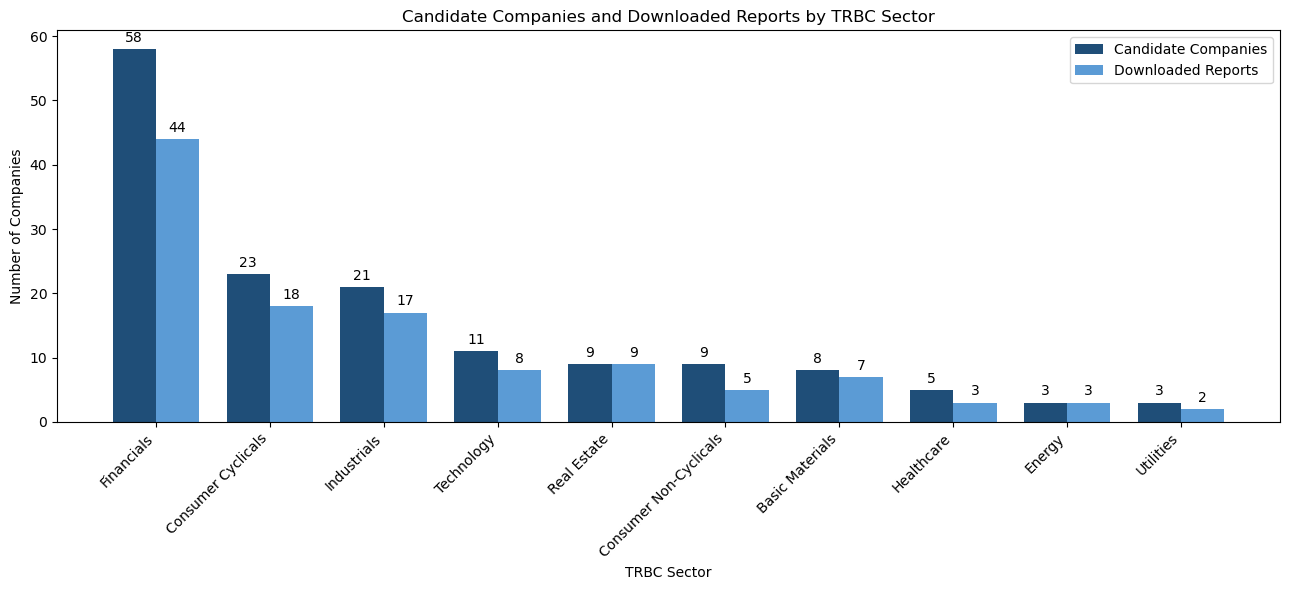

Chart saved as: Notebook01_Candidate_and_Downloaded_Reports_by_Sector.png


In [41]:
chart_data = sector_collection[
    sector_collection["TRBC Sector"] != "Total"
].copy()

x = np.arange(len(chart_data))
width = 0.38

fig, ax = plt.subplots(figsize=(13, 6))

candidate_bars = ax.bar(
    x - width / 2,
    chart_data["Candidate Companies"],
    width,
    label="Candidate Companies",
    color=PROJECT_COLOUR
)

download_bars = ax.bar(
    x + width / 2,
    chart_data["Downloaded Reports"],
    width,
    label="Downloaded Reports",
    color="#5B9BD5"
)

ax.bar_label(candidate_bars, padding=3)
ax.bar_label(download_bars, padding=3)

ax.set_title("Candidate Companies and Downloaded Reports by TRBC Sector")
ax.set_xlabel("TRBC Sector")
ax.set_ylabel("Number of Companies")
ax.set_xticks(x)
ax.set_xticklabels(
    chart_data["TRBC Sector"],
    rotation=45,
    ha="right"
)
ax.legend()

plt.tight_layout()

chart_file = (
    OUTPUT_FOLDER
    / "Notebook01_Candidate_and_Downloaded_Reports_by_Sector.png"
)

plt.savefig(chart_file, dpi=300, bbox_inches="tight")
plt.show()

print(f"Chart saved as: {chart_file.name}")

## 32. Create the Report-Validation Input for Notebook 2

I retained only companies with a successfully downloaded report and confirmed that each company had one report record. When the minimum target of 100 reports was achieved, I exported the dataset required for PDF validation and text extraction in Notebook 2.



In [42]:
downloaded_reports_df = (
    report_register[
        report_register["Download Status"] == "Downloaded"
    ]
    .copy()
    .reset_index(drop=True)
)

print(f"Downloaded company reports: {len(downloaded_reports_df)}")
print(
    "Duplicate companies:",
    downloaded_reports_df["Company Name"].duplicated().sum()
)
print(
    "Duplicate PDF hashes:",
    downloaded_reports_df["SHA256"].duplicated().sum()
)
print(
    "Missing file paths:",
    downloaded_reports_df["File Path"].isna().sum()
)

if len(downloaded_reports_df) >= 100:
    notebook2_file = (
        DATA_FOLDER
        / "Notebook02_Report_Validation_Input.xlsx"
    )

    downloaded_reports_df.to_excel(
        notebook2_file,
        index=False
    )

    print(f"Notebook 2 input saved as: {notebook2_file.name}")
    print("Notebook 1 minimum target achieved.")
else:
    print(f"Additional valid reports required: {100 - len(downloaded_reports_df)}")

Downloaded company reports: 116
Duplicate companies: 0
Duplicate PDF hashes: 0
Missing file paths: 0
Notebook 2 input saved as: Notebook02_Report_Validation_Input.xlsx
Notebook 1 minimum target achieved.


## 33. Save the Final Notebook 1 Audit

I saved the final report register, download-status summary and sector-coverage analysis in one audit workbook. This provides a reproducible record of the population, sampling and report-collection process.



In [43]:
audit_file = DATA_FOLDER / "Notebook01_Final_Report_Collection_Audit.xlsx"

with pd.ExcelWriter(audit_file) as writer:
    report_register.to_excel(
        writer,
        sheet_name="Report Register",
        index=False
    )

    status_summary.to_excel(
        writer,
        sheet_name="Download Summary",
        index=False
    )

    sector_collection.to_excel(
        writer,
        sheet_name="Sector Coverage",
        index=False
    )

print(f"Final audit saved as: {audit_file.name}")
print(f"Candidate companies: {len(report_register)}")
print(f"Downloaded reports: {len(downloaded_reports_df)}")
print(f"Unresolved companies: {len(report_register) - len(downloaded_reports_df)}")

Final audit saved as: Notebook01_Final_Report_Collection_Audit.xlsx
Candidate companies: 150
Downloaded reports: 116
Unresolved companies: 34


## 34. Complete the Final Reproducibility Checks

I completed the final validation checks to confirm that the candidate sample, report register and downloaded report dataset satisfied the study requirements before proceeding to Notebook 2.


In [44]:
validation_checks = pd.DataFrame({
    "Validation Check": [
        "Candidate sample contains 150 companies",
        "Report register contains 150 companies",
        "At least 100 reports were downloaded",
        "One report record per company",
        "No duplicate PDF hashes",
        "All downloaded files exist",
        "All report years are between 2022 and 2025",
        "All report types are eligible"
    ],
    "Passed": [
        len(candidate_df) == 150,
        len(report_register) == 150,
        len(downloaded_reports_df) >= 100,
        downloaded_reports_df["Company Name"].is_unique,
        downloaded_reports_df["SHA256"].is_unique,
        downloaded_reports_df["File Path"].apply(
            lambda path: Path(path).exists()
        ).all(),
        downloaded_reports_df["Report Year"].isin(
            [2022, 2023, 2024, 2025]
        ).all(),
        downloaded_reports_df["Report Type"].isin(
            ["Annual Report", "Sustainability Report", "ESG Report"]
        ).all()
    ]
})

validation_checks["Result"] = validation_checks["Passed"].map({
    True: "Passed",
    False: "Failed"
})

display(
    validation_checks[
        ["Validation Check", "Result"]
    ].style.hide(axis="index")
)

if validation_checks["Passed"].all():
    print("Notebook 1 validation passed.")
    print("The workflow can proceed to Notebook 2.")
else:
    print("Notebook 1 validation failed.")
    print("Review the checks marked as Failed.")

Validation Check,Result
Candidate sample contains 150 companies,Passed
Report register contains 150 companies,Passed
At least 100 reports were downloaded,Passed
One report record per company,Passed
No duplicate PDF hashes,Passed
All downloaded files exist,Passed
All report years are between 2022 and 2025,Passed
All report types are eligible,Passed


Notebook 1 validation passed.
The workflow can proceed to Notebook 2.



## Notebook Summary and Reproducibility Note

In this notebook, I loaded and validated the FTSE 350 population dataset containing 350 companies. I excluded 15 companies without an LSEG ESG Score, producing an eligible population of 335 companies.

I applied proportionate stratified random sampling using the largest-remainder method and a fixed random seed of 42. This produced a reproducible candidate sample of 150 companies across the ten TRBC sectors.

I used the official company websites recorded in the population dataset to search for reports published between 2022 and 2025. I prioritised annual reports, followed by sustainability and ESG reports. Three discovery levels were applied: official website crawling, deeper webpage and sitemap searching, and search-engine-assisted discovery restricted to official company domains.

I retained only one report per company. PDF headers, file sizes and completion markers were checked, while SHA-256 hashes were used to prevent duplicate files. The final collection contained **{downloaded_total} unique company reports**, while **{unresolved_total} companies remained unresolved**.

The candidate sample, report register, sector audit and downloaded-report dataset were saved to support independent execution of Notebook 2.

### Main outputs

- `Notebook01_150_Company_Candidate_Sample.xlsx`
- `Notebook01_Report_Collection_Register.xlsx`
- `Notebook01_Final_Report_Collection_Audit.xlsx`
- `Notebook02_Report_Validation_Input.xlsx`
- `Notebook01_Eligible_Population_by_Sector.png`
- `Notebook01_Candidate_and_Downloaded_Reports_by_Sector.png`
- Valid PDF reports in `report/original_reports`

**Next stage:** Notebook 2 will validate the downloaded PDFs, extract and clean their text, apply the minimum 5,000-word eligibility requirement and select the final 100-company analytical sample.
"""))